In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("AirAware_Dataset.csv")

print(df.head())


  Sensor_ID            Timestamp   PM2_5    PM10  CO2_Level  NO2_Level  \
0  SEN-1000  2026-03-30 23:57:57   96.76  143.84    1122.01      92.44   
1  SEN-1001  2026-05-18 01:35:57  237.93  170.97    1032.41     135.68   
2  SEN-1002  2026-05-25 22:09:57  184.34  300.55     687.54     103.47   
3  SEN-1003  2026-03-21 16:51:57  151.67  125.60    1635.99      19.58   
4  SEN-1004  2026-05-03 03:59:57   43.22  305.68    1348.57      37.48   

   SO2_Level  Temperature_C  Humidity_%  Wind_Speed_kmh  Traffic_Density  \
0      87.87          13.23       67.86           36.56                8   
1      22.96          12.13       54.45            2.33                5   
2      42.25          31.15       92.34           36.74                1   
3      79.93          43.81       36.42            5.38                4   
4      58.37          27.60       64.09           42.62                3   

   Industrial_Activity Air_Quality_Label  
0                    1         Clean Air  
1           

In [3]:
df.drop(["Sensor_ID", "Timestamp"], axis=1, inplace=True)

In [4]:
encoder = LabelEncoder()
df["Air_Quality_Label"] = encoder.fit_transform(df["Air_Quality_Label"])


In [5]:
X = df.drop("Air_Quality_Label", axis=1)
y = df["Air_Quality_Label"]

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [9]:
y_pred = model.predict(X_test)

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.998

Confusion Matrix:

[[479   1]
 [  1 519]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       480
           1       1.00      1.00      1.00       520

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



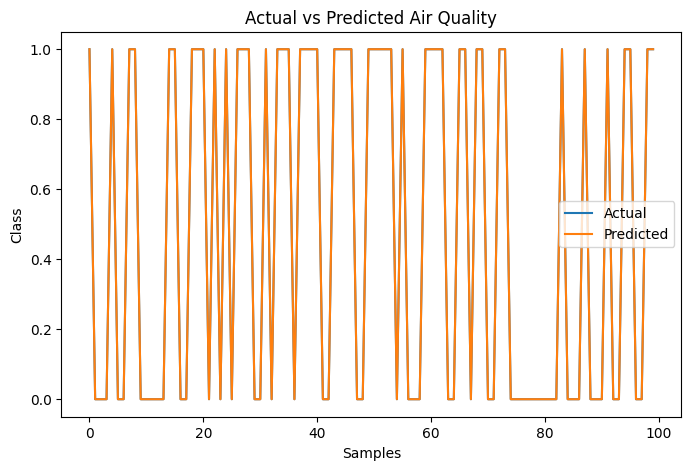

In [11]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.title("Actual vs Predicted Air Quality")
plt.xlabel("Samples")
plt.ylabel("Class")

plt.legend()

plt.show()


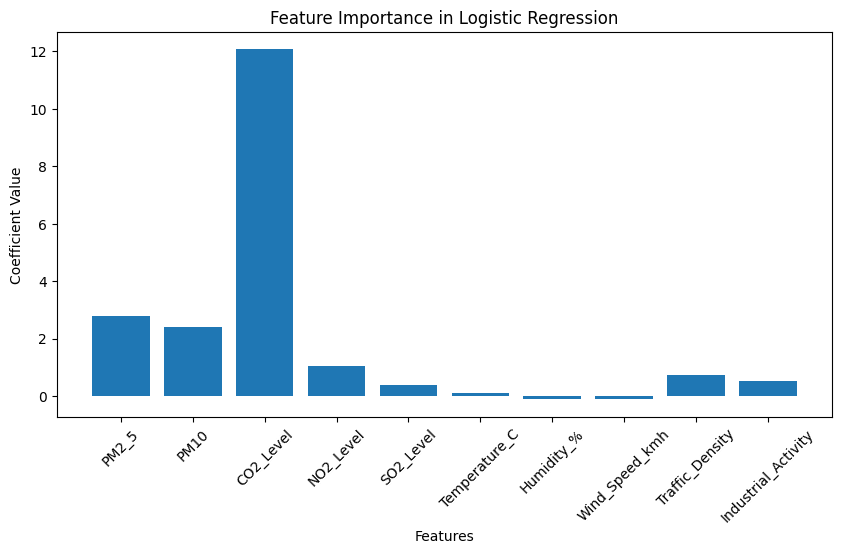

In [12]:

importance = model.coef_[0]

feature_names = X.columns

plt.figure(figsize=(10,5))

plt.bar(feature_names, importance)

plt.xticks(rotation=45)

plt.title("Feature Importance in Logistic Regression")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")

plt.show()